In [2]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils import data
import matplotlib.pyplot as plt
from collections import defaultdict

from tqdm import tqdm

In [3]:
df = torch.load(r'C:\Users\Admin\Documents\GitHub\PLUM_implementation\data\heterodata_object12.pt', weights_only=False,map_location=torch.device('cpu'))

In [4]:
df

HeteroData(
  item={
    x=[12101, 100],
    text=[12101],
    is_train=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)

In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim
        self.encoder = nn.Sequential()
        self.dims = [input_dim] + hidden_dims + [output_dim]
        for ind, inp_dim in enumerate(self.dims[:-1]):
            out_dim = self.dims[ind+1]
            cur_enc = nn.Linear(inp_dim, out_dim, bias = False)
            self.encoder.append(cur_enc)
            if ind != len(self.dims) - 2:
                self.encoder.append(nn.ReLU())
        
    def forward(self, x):
        return self.encoder(x)

In [6]:
class Codebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta):
        super().__init__()
        self.beta = beta
        self.emb = nn.Embedding(codebook_size, emb_dim)
        nn.init.uniform_(self.emb.weight, -1.0, 1.0)

    def forward(self, x):
        code = self.emb.weight  
        dist = (
            (x ** 2).sum(dim=1, keepdim=True)
            + (code ** 2).sum(dim=1)
            - 2 * x @ code.T
        )
        ids = dist.argmin(dim=1)
        emb = self.emb(ids)
        loss = (
            F.mse_loss(emb, x.detach()) +
            self.beta * F.mse_loss(x, emb.detach())
        )
        emb_st = x + (emb - x).detach()
        return loss, emb_st, ids


In [7]:
class RQVAE(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim,n_codebooks, n_layers, beta):
        super().__init__()
        self.inp_size = inp_size
        self.hidden_sizes = hidden_sizes
        self.emb_dim = embed_dim
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[-1::-1], inp_size)
        self.layers = nn.ModuleList(modules=[Codebook(n_codebooks, embed_dim, beta) for _ in range(n_layers)])
    
    def forward(self,x):
        encoded = self.enc(x)
        r = encoded
        q_losses = 0
        sids = []
        e_sum = torch.zeros(size=(x.shape[0], self.emb_dim), device = 'cuda' if torch.cuda.is_available() else 'cpu')
        for layer in self.layers:
            q_loss, emb, ids = layer(r)
            r = r-emb.detach()
            q_losses+= q_loss
            e_sum += emb
            sids.append(ids)
        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x, dec) 
        loss = q_losses + rec_loss
        return q_losses, rec_loss, loss, sids
            
            

In [8]:
class RQVAE_modified(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers, beta):
        super().__init__()
        self.inp_size = inp_size
        self.hidden_sizes = hidden_sizes
        self.emb_dim = embed_dim
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[-1::-1], inp_size)
        self.layers = nn.ModuleList(modules=[Codebook(2048//(2**i), embed_dim, beta) for i in range(n_layers)])
    
    def forward(self,x):
        encoded = self.enc(x)
        r = encoded
        q_losses = 0
        sids = []
        e_sum = torch.zeros_like(encoded)
        level_mask = torch.randint(1, len(self.layers)+1, size=(1,)).item()
        for level, layer in enumerate(self.layers):
            mask = level < level_mask
            q_loss, emb, ids = layer(r)
            r = r-emb.detach()
            q_losses+= q_loss
            e_sum += emb * mask
            sids.append(ids)
        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x, dec) 
        loss = q_losses + rec_loss
        return q_losses, rec_loss, loss, sids
            

In [9]:
class Data_Embeddings(Dataset):
    def __init__(self, data, related):
        super().__init__()
        self.data = data
        self.related = related
        
    def __getitem__(self, index):
        return index, self.data[index]
        
    def __len__(self):
        return self.data.shape[0]

In [10]:
def unique_per_level(SIDs):
    uns = []
    for sid in SIDs:
        uns.append(sid.unique().numel())
    return torch.tensor(uns, device = device)

In [11]:
def entropy_per_level(all_sids, codebook_size):
    entropies = []

    for level_ids in all_sids:
        ids = torch.cat(level_ids).view(-1)
        counts = torch.bincount(ids, minlength=codebook_size).float()
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropy = -(probs * torch.log2(probs)).sum()
        entropies.append(entropy)

    return torch.tensor(entropies, device='cpu').detach()


In [12]:
embeds = df['item'].x
related = list(range(len(embeds)))
ds = Data_Embeddings(embeds,related)

In [13]:
train_rq, val_rq = data.random_split(ds, [0.9, 0.1])
print(len(val_rq))

1210


In [14]:
dl_train_rq = DataLoader(train_rq, batch_size = 1024, shuffle = True)
dl_val_rq = DataLoader(val_rq, batch_size = len(val_rq), shuffle= False)

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [16]:
lr = 0.4
n_layers = 3
beta = 0.25
hidden_sizes = [512, 256, 128]
embed_dim = 32
codebook_num = 2048
n_ep = 100

In [62]:
def train_model(model, n_ep, optimizer, dl_train, dl_val, n_layers, device):
    history = {
    'train_total_loss':[],
    'train_recon_loss':[],
    'train_rq_loss':[],
    'train_sids_num':[],
    'train_entropy':[],
    'val_total_loss':[],
    'val_recon_loss':[],
    'val_rq_loss':[],
    'val_sids_num':[],
    'val_entropy':[]}
    
    for e in range(n_ep):
        model.train()
        loss_total_avg = 0 
        loss_recon_avg = 0 
        loss_rq_avg = 0 
        sids_number_avg = torch.zeros(size=(n_layers,), device = device) 
        epoch_sids = [[] for _ in range(n_layers)]
        train_tqdm = tqdm(dl_train, leave = False, desc=f'train {e+1}/{n_ep}') 
        
        for ind, emb in train_tqdm:
            emb = emb.to(device)
            pred = model(emb)
            q_loss, r_loss, loss,  sids = pred
            loss_recon = r_loss
            un_sids = unique_per_level(sids)
            for level in range(n_layers):
                epoch_sids[level].append(sids[level])

            total_loss = loss
            train_tqdm.set_postfix( total=f"{total_loss.item():.4f}", quant=f"{q_loss.item():.4f}", recon=f"{loss_recon.item():.4f}", uniq = f"{un_sids.tolist()}") 
            
            optimizer.zero_grad() 
            total_loss.backward() 
            optimizer.step()
            
            loss_total_avg += total_loss.item() 
            loss_recon_avg += loss_recon.item() 
            loss_rq_avg += q_loss.item() 
            sids_number_avg += un_sids
            
        loss_total_avg = loss_total_avg/ len(dl_train) 
        loss_recon_avg = loss_recon_avg/ len(dl_train) 
        loss_rq_avg = loss_rq_avg/ len(dl_train) 
        sids_number_avg = sids_number_avg/len(dl_train)
        entropy_levels = entropy_per_level(epoch_sids, codebook_num)

        history['train_total_loss'].append(loss_total_avg) 
        history['train_recon_loss'].append(loss_recon_avg)
        history['train_rq_loss'].append(loss_rq_avg) 
        history['train_sids_num'].append(sids_number_avg.detach().cpu())
        history['train_entropy'].append(entropy_levels)

        model.eval()
        val_tqdm = tqdm(dl_val, leave=False, desc = f'val {e+1}/{n_ep}') 
        loss_total_avg = 0 
        loss_recon_avg = 0 
        loss_rq_avg = 0 
        sids_number_avg = torch.zeros(size=(n_layers,), device = device) 
        epoch_sids = [[] for _ in range(n_layers)]


        with torch.no_grad(): 
            for ind, emb in val_tqdm: 
                emb = emb.to(device) 
                pred = model(emb) 
                q_loss, r_loss, loss,  sids = pred
                loss_recon = r_loss
                un_sids = unique_per_level(sids)
                for level in range(n_layers):
                    epoch_sids[level].append(sids[level])
                total_loss = loss
                val_tqdm.set_postfix( total=f"{total_loss.item():.4f}", quant=f"{q_loss:.4f}", recon=f"{loss_recon.item():.4f}",uniq = f"{un_sids.tolist()}") 
                
                loss_total_avg += total_loss.item() 
                loss_recon_avg += loss_recon.item()
                loss_rq_avg += q_loss.item()
                sids_number_avg += un_sids
                
            loss_total_avg = loss_total_avg/ len(dl_val) 
            loss_recon_avg = loss_recon_avg/ len(dl_val)
            loss_rq_avg = loss_rq_avg/ len(dl_val)
            sids_number_avg = sids_number_avg/len(dl_val) 
            entropy_levels = entropy_per_level(epoch_sids, codebook_num)

            history['val_total_loss'].append(loss_total_avg) 
            history['val_recon_loss'].append(loss_recon_avg) 
            history['val_rq_loss'].append(loss_rq_avg) 
            history['val_sids_num'].append(sids_number_avg.detach().cpu()) 
            history['val_entropy'].append(entropy_levels) 

            
    return history
        

In [70]:
rq_vae = RQVAE(embeds.shape[1], hidden_sizes, embed_dim, codebook_num, n_layers, beta).to(device)
optimizer = optim.Adagrad(rq_vae.parameters(), lr=lr)

In [142]:
rq_vae.load_state_dict(torch.load(r'Downloads/best_rqvae.pth',map_location=torch.device('cpu')))

<All keys matched successfully>

In [102]:
rq_vae_mod = RQVAE_modified(embeds.shape[1], hidden_sizes, embed_dim, n_layers, beta).to(device)
optimizer_mod = optim.Adagrad(rq_vae_mod.parameters(), lr=lr)

In [104]:
history_mod = train_model(rq_vae_mod, n_ep, optimizer_mod, dl_train_rq, dl_val_rq, n_layers, device)

In [74]:
history = train_model(rq_vae, n_ep, optimizer, dl_train_rq, dl_val_rq, n_layers, device)

In [144]:
def sids_analyze(model, df, device):
    model.eval()
    sid_to_ids = defaultdict(list)
    id_to_sid = {}
    with torch.no_grad():
        for ind, item_id in enumerate(df['item'].text):
            emb = df['item'].x[ind].to(device)
            emb = emb.view(1, -1)
            _, _, _, sids = model(emb)
            sid_tuple = tuple(level.item() for level in sids)
            sid_to_ids[sid_tuple].append(item_id)
            id_to_sid[item_id] = sid_tuple

    id_to_fullsid = {}
    
    for sid, ids in sid_to_ids.items():
        if len(ids) == 1:
            id_to_fullsid[ids[0]] = sid
        else:
            for cnt, item_id in enumerate(ids):
                id_to_fullsid[item_id] = (*sid, cnt)
                
    return {
        "id_to_sid": id_to_sid,
        "sid_to_ids": sid_to_ids,
        "id_to_fullsid": id_to_fullsid
    }



In [146]:
def calculate_metrics(sid_to_ids, ds):
    n_unique_sid = len(sid_to_ids)
    n_collisions = sum(len(v) - 1 for v in sid_to_ids.values())
    max_cluster = max(len(v) for v in sid_to_ids.values())
    cfr = (len(ds) - n_collisions) / len(ds)
    return {'n_unique_sid': n_unique_sid,
            'n_collisions': n_collisions,
            'max_cluster': max_cluster,
            'collision_free_ratio': cfr}
            

In [148]:
rq_vae_sids = sids_analyze(rq_vae, df, device)
rq_vae_mod_sids = sids_analyze(rq_vae_mod, df, device)

In [149]:
metrics_rq_vae = calculate_metrics(rq_vae_sids['sid_to_ids'], ds)
metrics_rq_vae_mod = calculate_metrics(rq_vae_mod_sids['sid_to_ids'],ds)
metrics = {'RQ_VAE': metrics_rq_vae,
            'RQ_VAE_MODIFIED': metrics_rq_vae_mod}

In [150]:
stats = pd.DataFrame(metrics).T
stats

,n_unique_sid,n_collisions,max_cluster,collision_free_ratio
RQ_VAE,11213.0,888.0,6.0,0.926618
RQ_VAE_MODIFIED,875.0,11226.0,1986.0,0.072308


In [76]:
def plot_losses(history):
    epochs = range(1, len(history["train_total_loss"]) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_total_loss"], label="train total")
    plt.plot(epochs, history["val_total_loss"], label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total loss")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_recon_loss"], label="train recon")
    plt.plot(epochs, history["train_rq_loss"], label="train quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train losses")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_recon_loss"], label="val recon")
    plt.plot(epochs, history["val_rq_loss"], label="val quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Val losses")
    plt.yscale("log")
    plt.legend()
    plt.savefig(fname = 'res_2.png')
    plt.show()


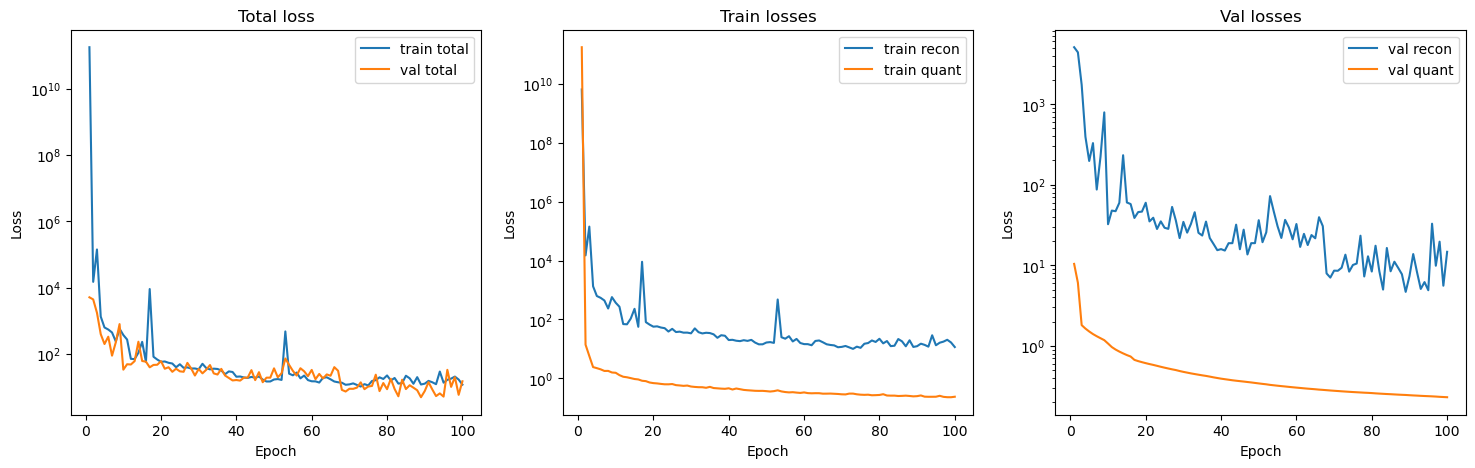

In [78]:
plot_losses(history)

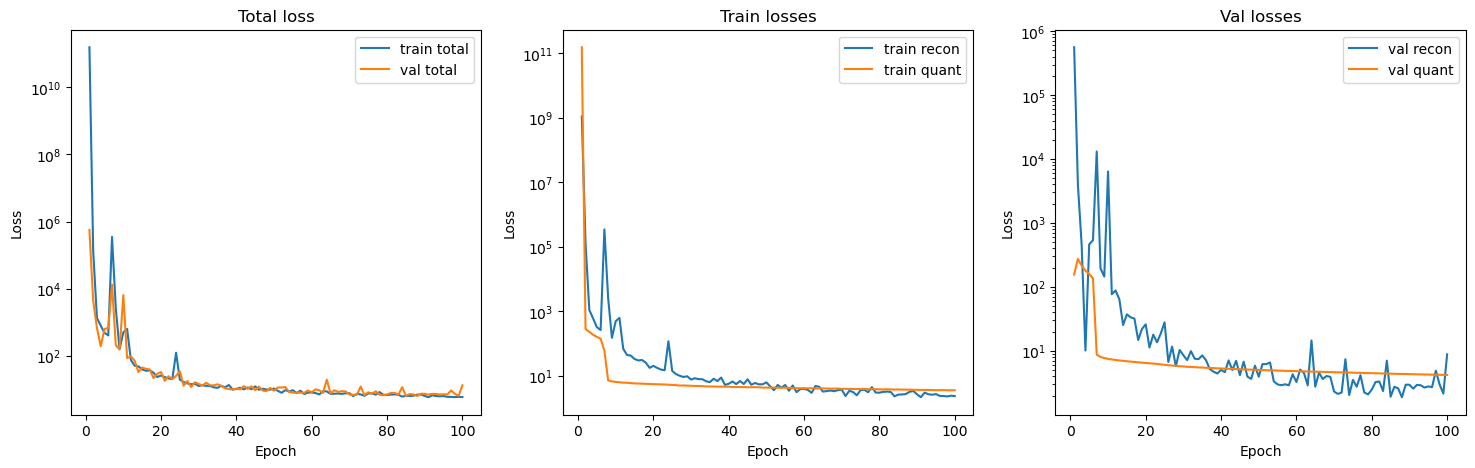

In [106]:
plot_losses(history_mod)

In [79]:
def plot_SIDS(history):
    epochs = range(1, len(history["val_sids_num"]) + 1)
    sids_val, sids_train = np.asarray(history["val_sids_num"]), np.asarray(history["train_sids_num"])
    
    plt.figure(figsize= (18, 12))
    for i in range(sids_val.shape[1]):
        plt.subplot(3, 1, i+1)
        
        plt.plot(epochs, sids_train[:, i], label=f"train sids level {i}")
        plt.plot(epochs, sids_val[:, i], label=f"val sids number {i}")
        plt.xlabel("Epoch")
        plt.ylabel("SID number")
        plt.legend()
    plt.savefig(fname = 'sids_plot.png')
    plt.show()

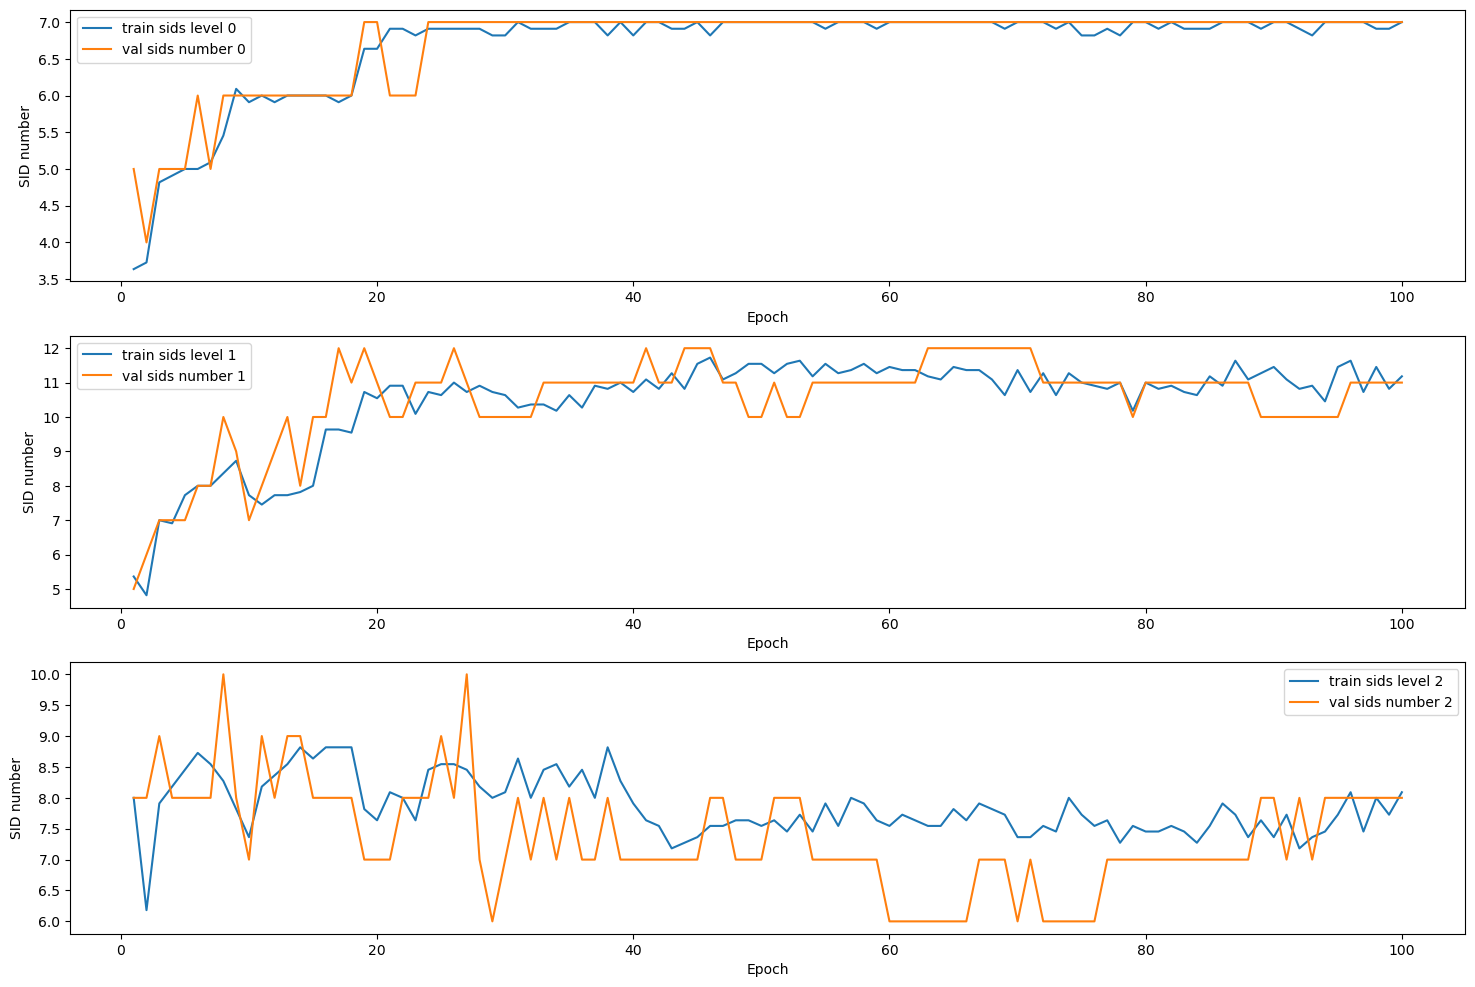

In [82]:
plot_SIDS(history)

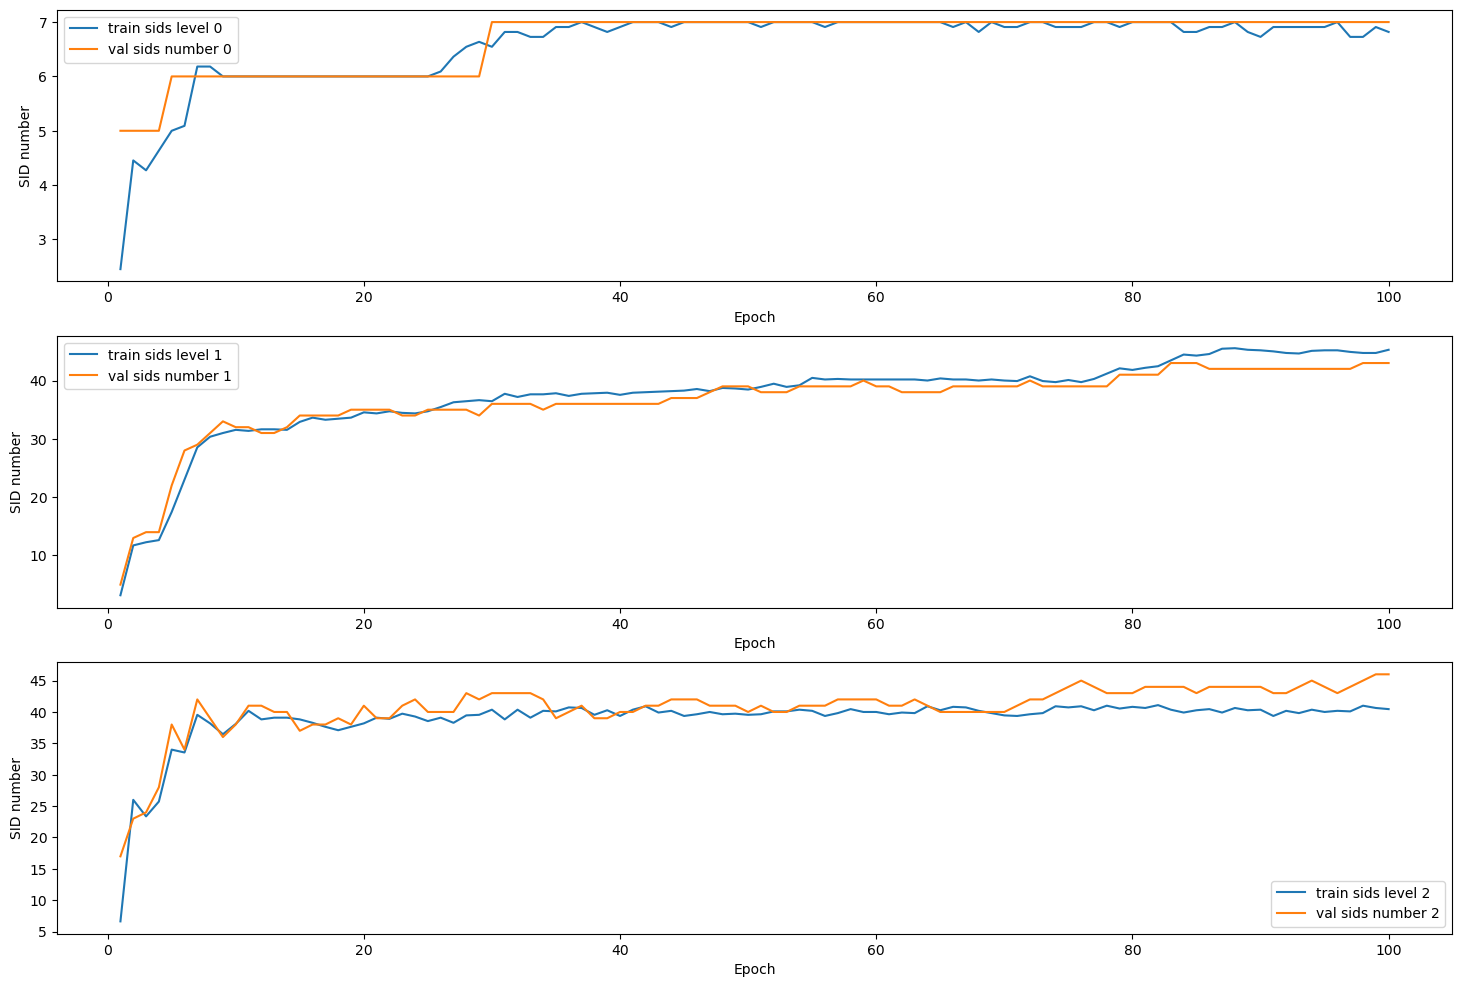

In [108]:
plot_SIDS(history_mod)

In [83]:
def plot_entropy(history):
    epochs = range(1, len(history["val_entropy"]) + 1)

    entropy_train = np.asarray(history["train_entropy"])
    entropy_val = np.asarray(history["val_entropy"])

    plt.figure(figsize=(18, 12))

    for i in range(entropy_val.shape[1]):
        plt.subplot(entropy_val.shape[1], 1, i + 1)

        plt.plot(epochs, entropy_train[:, i], label=f"train entropy level {i}")
        plt.plot(epochs, entropy_val[:, i], label=f"val entropy level {i}")

        plt.xlabel("Epoch")
        plt.ylabel("Entropy")
        plt.legend()

    plt.savefig('entropy_plot.png')
    plt.show()


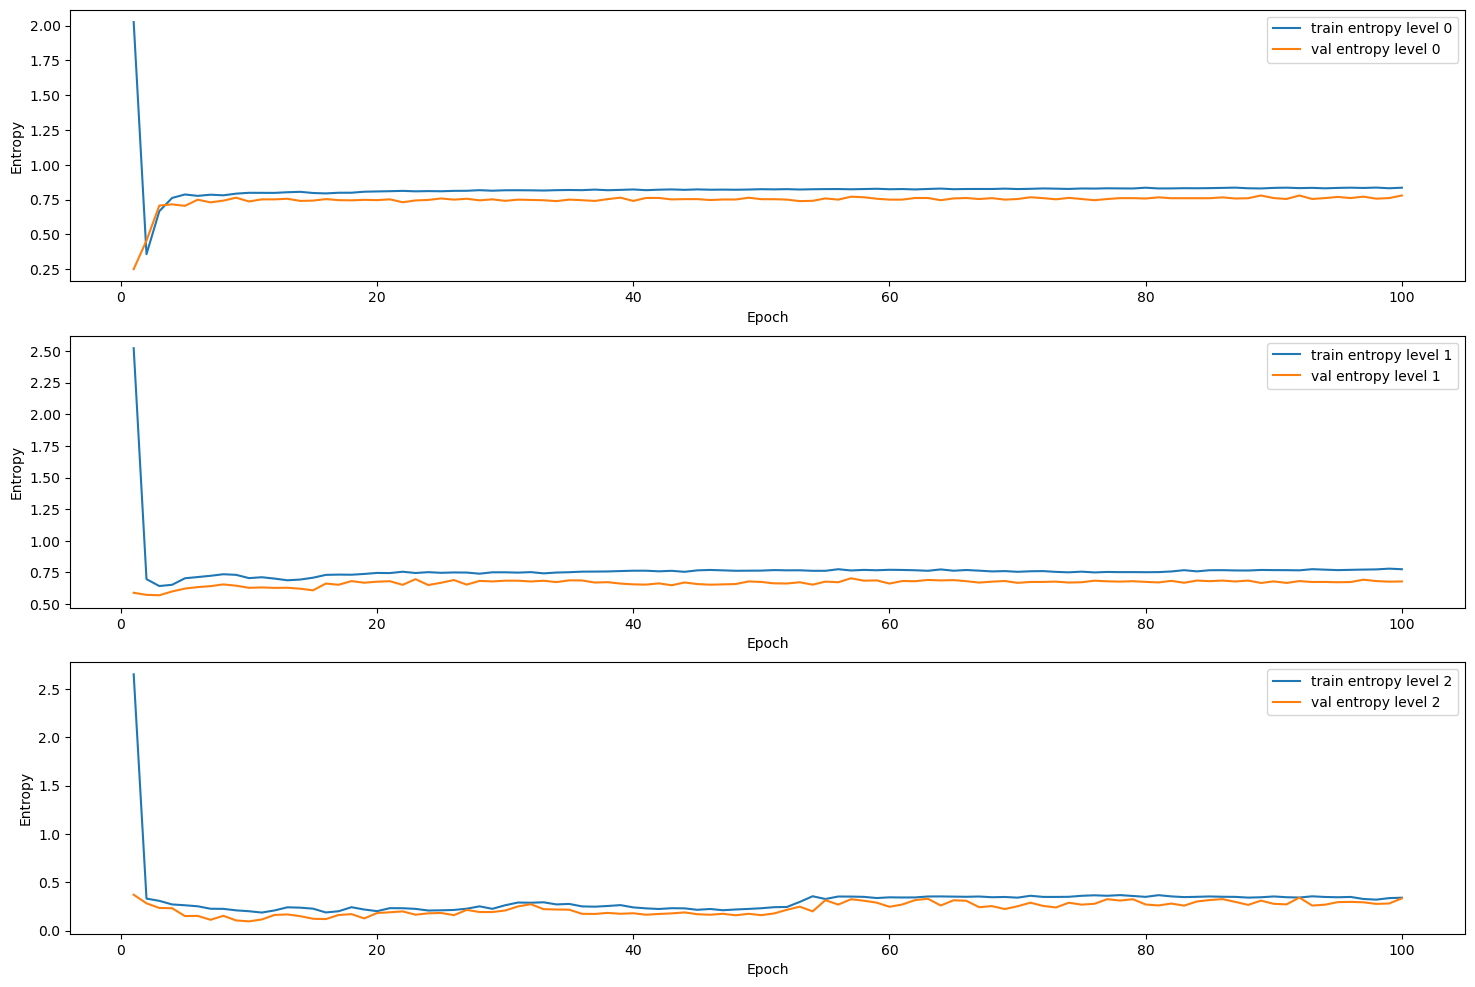

In [86]:
plot_entropy(history)

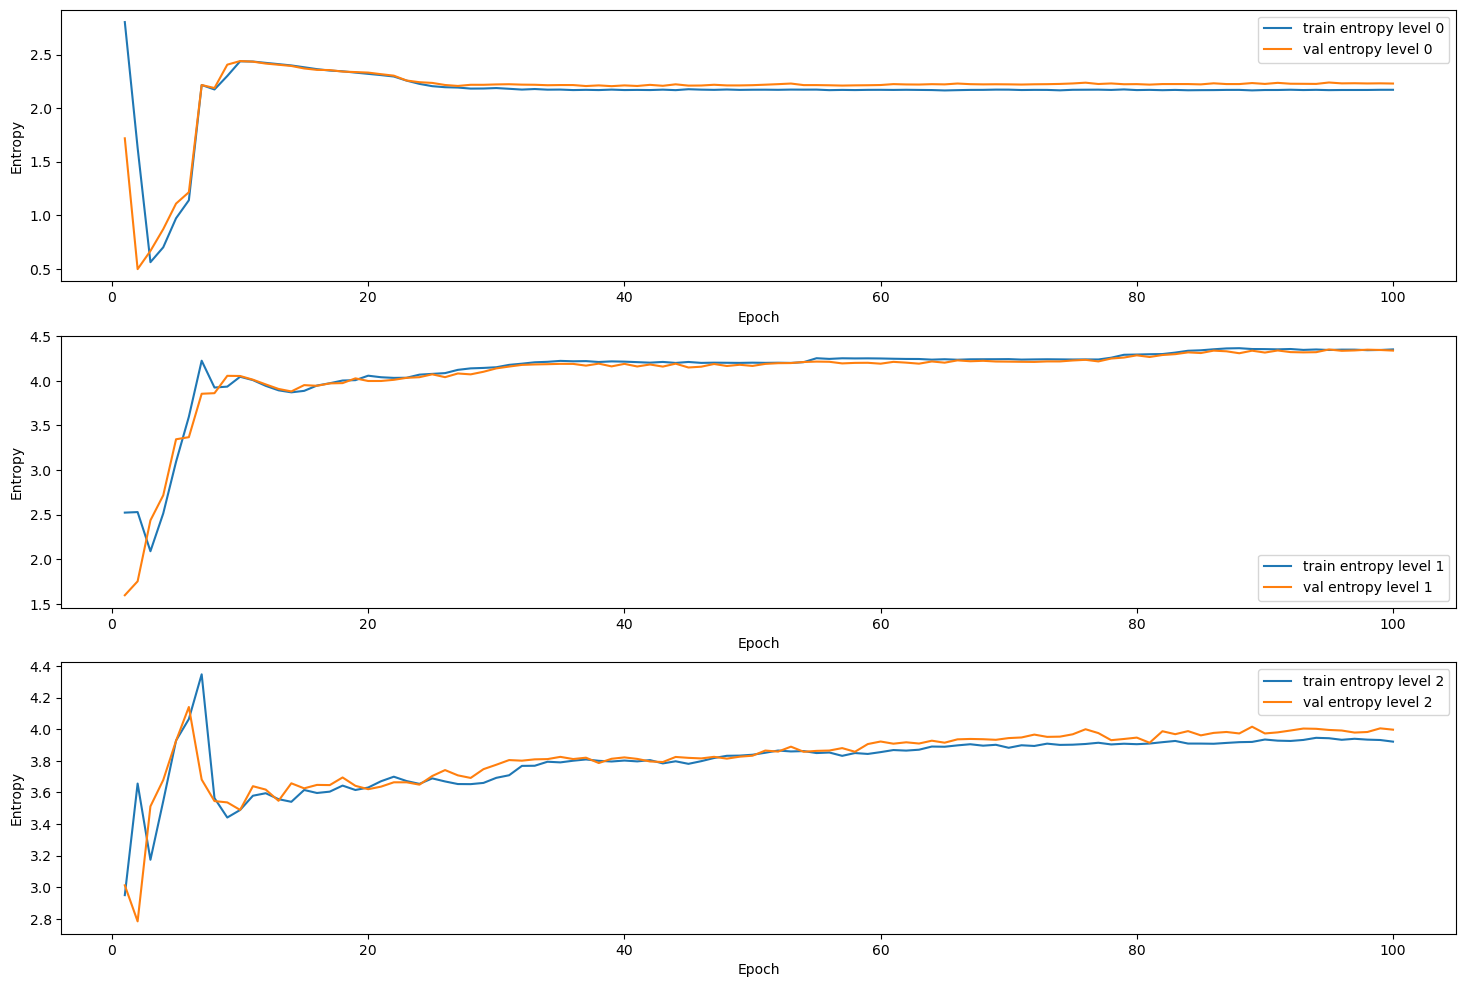

In [110]:
plot_entropy(history_mod)